In [482]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


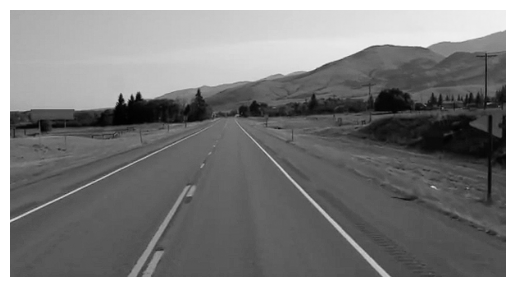

In [483]:
img = cv2.imread("Road-Lane-1.png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #type: ignore


plt.imshow(gray, cmap='gray')
plt.axis("off")
plt.show()

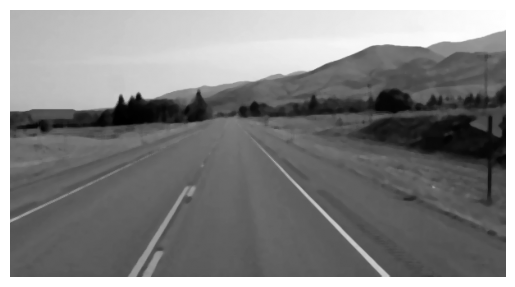

In [484]:
smooth = cv2.medianBlur(gray,5)
plt.imshow(smooth, cmap='gray')
plt.axis("off")
plt.show()

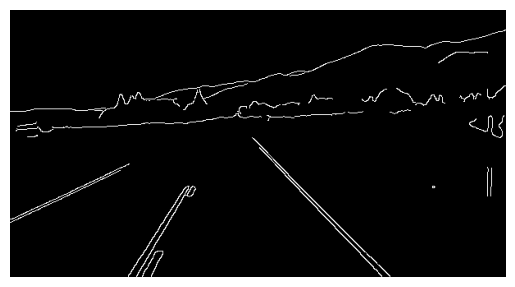

In [485]:
edges = cv2.Canny(smooth,100,200)
plt.imshow(edges, cmap='gray')
plt.axis("off")
plt.show()

In [486]:
def preprocess_image(img_array):

    gray_img = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
    
    blurred_img = cv2.medianBlur(gray_img, 5)
    
    edges_img = cv2.Canny(blurred_img, 100, 200)
    plt.imshow(edges_img, cmap='gray')
    plt.axis("off")
    plt.show()

    return edges_img

In [487]:
def apply_roi_mask(edges_img):

    height, width = edges_img.shape

    # coordinates for a trapezoidal polygon
    bottom_left = (0, height)
    top_left = (0, int(height * 0.6))
    top_right = (int(width * 0.6), int(height * 0.7))
    bottom_right = (width, height)

    polygon = np.array([[bottom_left, top_left, top_right, bottom_right]], np.int32)

    mask = np.zeros_like(edges_img)

    cv2.fillPoly(mask, polygon, 255)   # Fill the trapezoidal polygon with white (255) # type: ignore

    masked_image = cv2.bitwise_and(edges_img, mask)
    plt.imshow(masked_image, cmap='gray')
    plt.axis("off")
    plt.show()
    return masked_image

In [488]:
def get_hough_accumulator(roi_edges):
   
    height, width = roi_edges.shape

    thetas = np.deg2rad(np.arange(-90 , 90))
    diag_len = int(np.sqrt(height**2 + width**2))
    accumulator = np.zeros((2 * diag_len, len(thetas)), dtype=np.uint64)

    y_idxs, x_idxs = np.nonzero(roi_edges)

    for i in range(len(x_idxs)):
        x = x_idxs[i]
        y = y_idxs[i]

        for t_idx in range(len(thetas)):
            theta = thetas[t_idx]
            rho = int(x * np.cos(theta) + y * np.sin(theta))  + diag_len
            accumulator[rho, t_idx] += 1


    plt.imshow(accumulator,cmap='hot',aspect='auto')
    plt.title("Hough Accumulator")
    plt.xlabel("Theta")
    plt.ylabel("Rho")
    plt.show()        

    return accumulator, thetas, diag_len

In [489]:
def extract_line_segments(accumulator, thetas, diag_len, threshold=90):

    left_lines = []
    right_lines = []
    center_lines = []

    for r in range(accumulator.shape[0]):
        for t in range(accumulator.shape[1]):
            if accumulator[r, t] > threshold:
                rho = r - diag_len
                theta = thetas[t]

                a = np.cos(theta)
                b = np.sin(theta)

                slope = -a / b
                intercept = rho / b

                if slope < -0.6:
                    left_lines.append((slope, intercept))
                elif slope > 0.6:
                    right_lines.append((slope, intercept))
                else:
                    center_lines.append((slope, intercept))

    def average_line(lines):   
        slopes = [l[0] for l in lines]
        intercepts = [l[1] for l in lines]
        
        avg_slope = np.mean(slopes)
        avg_intercept = np.mean(intercepts)
        
        return avg_slope, avg_intercept

    left_avg = average_line(left_lines)
    right_avg = average_line(right_lines)
    center_avg = average_line(center_lines)

    return left_avg, right_avg, center_avg

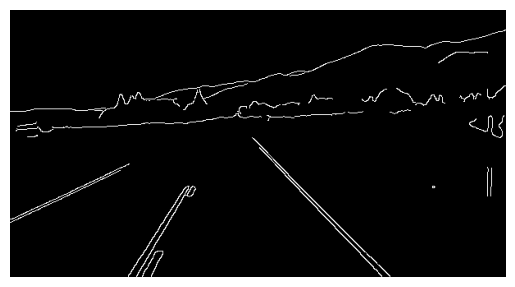

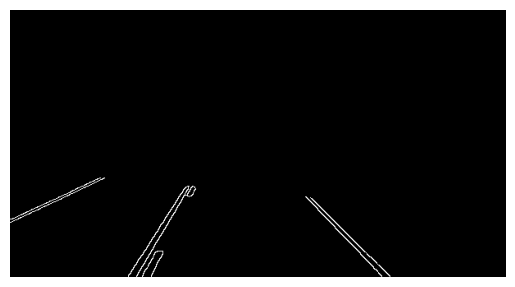

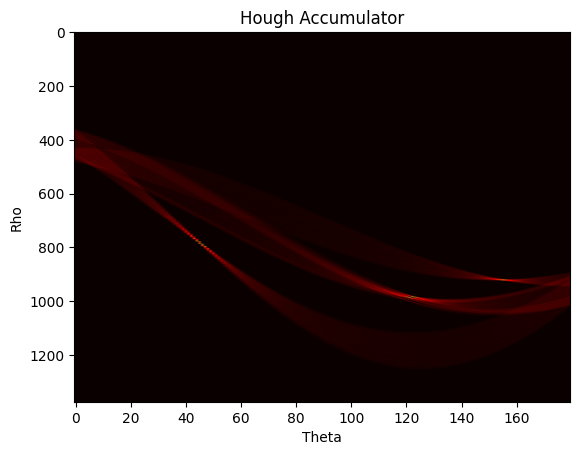

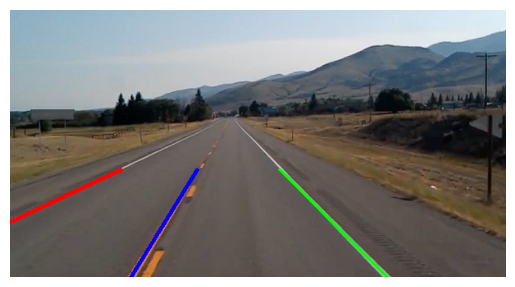

In [490]:

def draw_lane_lines(img, lines, y_bottom, y_top):
    img_copy = img.copy()
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)] # Blue, Green, Red

    for line, color in zip(lines, colors):
        slope, intercept = line

        if np.isnan(slope) or np.isnan(intercept) or abs(slope) < 1e-6:
            continue

        x1 = int((y_bottom - intercept) / slope)
        x2 = int((y_top - intercept) / slope)

        cv2.line(img_copy, (x1, y_bottom), (x2, y_top), color, 3)
            
    return img_copy

def lane_detection_pipeline(image_path):
    #Load image
    img = cv2.imread(image_path)

    #Preprocessing
    edges = preprocess_image(img)

    #ROI Masking
    roi_edges = apply_roi_mask(edges)

    #Hough Transform
    acc, thetas, d_len = get_hough_accumulator(roi_edges)

    #Extract and Average Lines
    left, right, center = extract_line_segments(acc, thetas, d_len)

    h, w = img.shape[:2] #type: ignore
    y_bottom = h
    y_top = int(h * 0.6)

    result_img = draw_lane_lines(img, [left, right, center], y_bottom, y_top)
    result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB) #type: ignore

    plt.imshow(result_img)
    plt.axis("off")
    plt.show()

    return result_img

# Execute the pipeline
final_result = lane_detection_pipeline("Road-Lane-1.png")


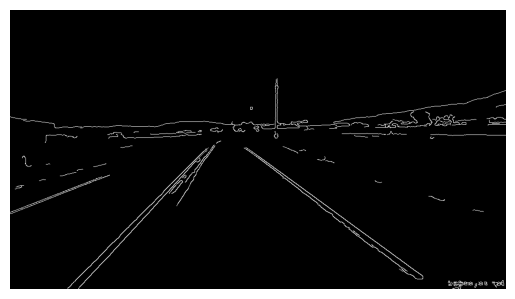

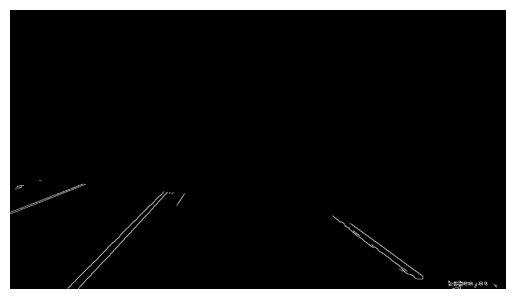

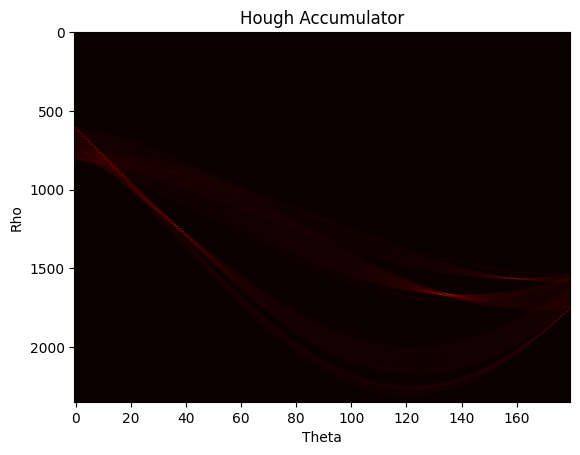

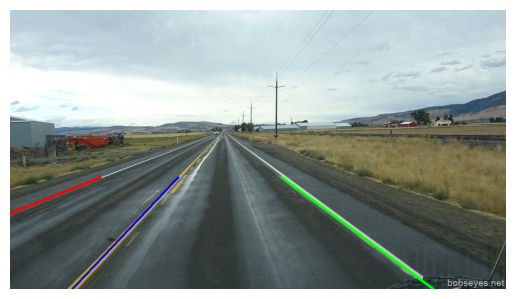

In [491]:
img_1 = lane_detection_pipeline("Road-Lane-3.png")


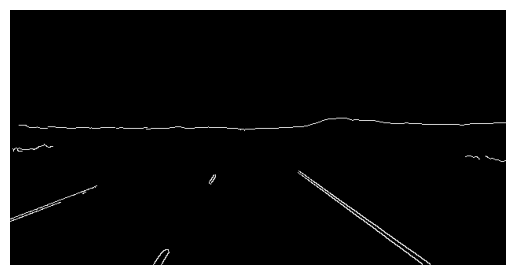

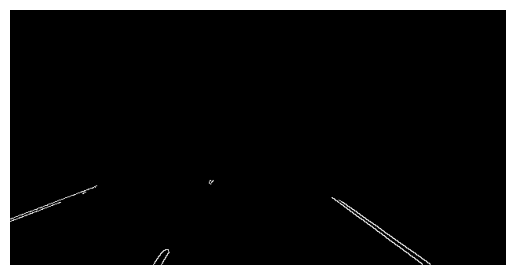

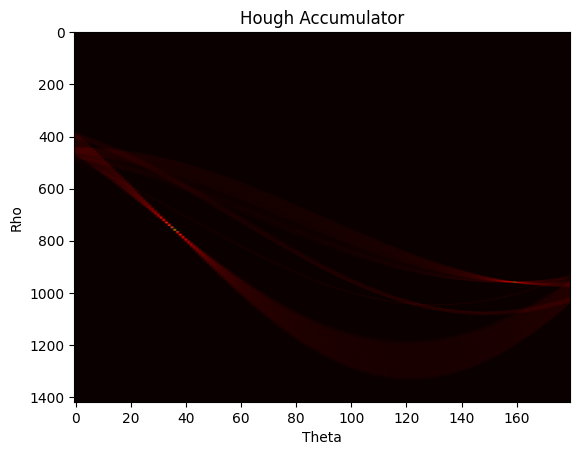

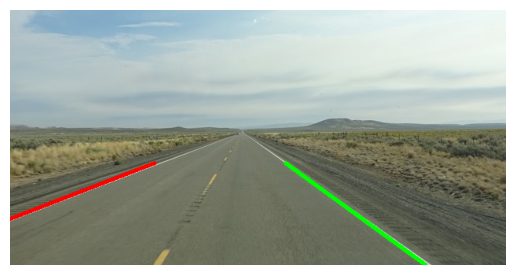

In [492]:
img_2 = lane_detection_pipeline("Road-Lane-2.png")

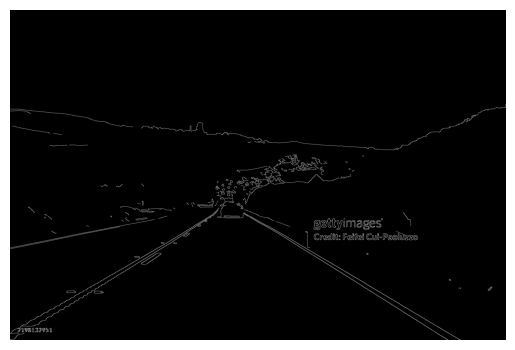

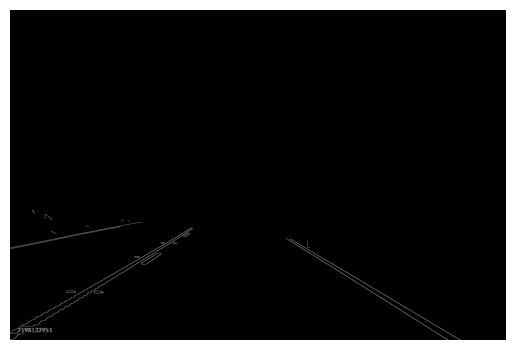

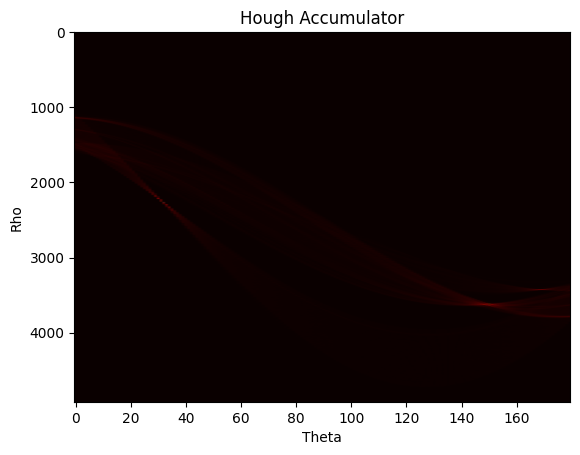

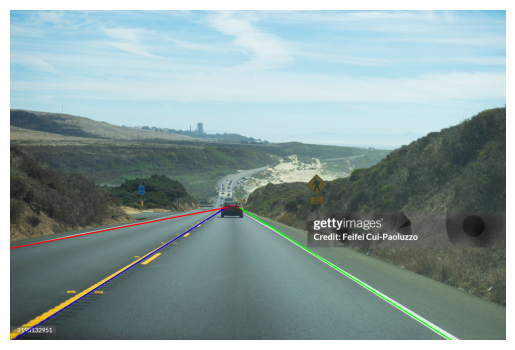

In [494]:
img_4= lane_detection_pipeline("Road-Lane-7.png")

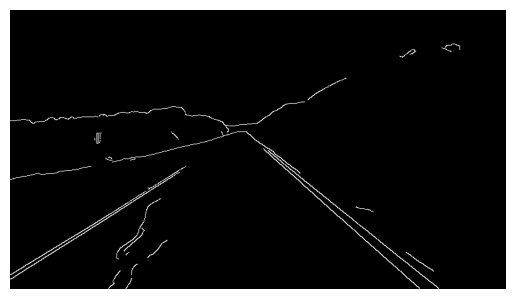

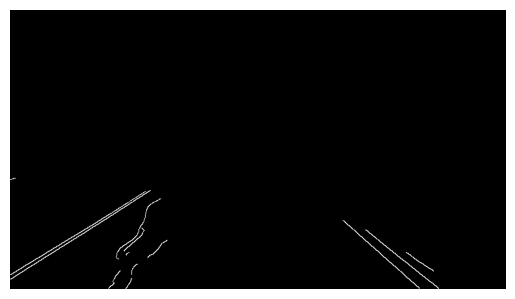

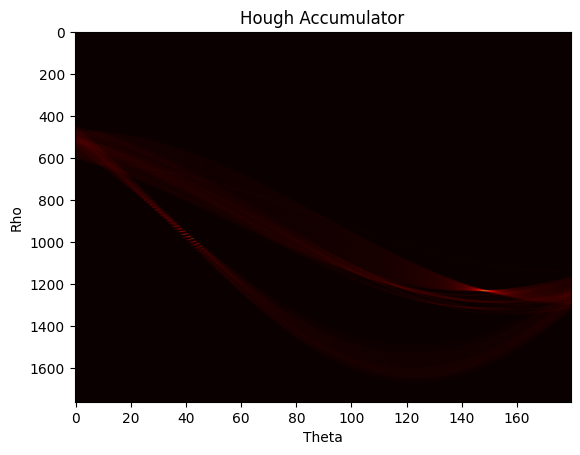

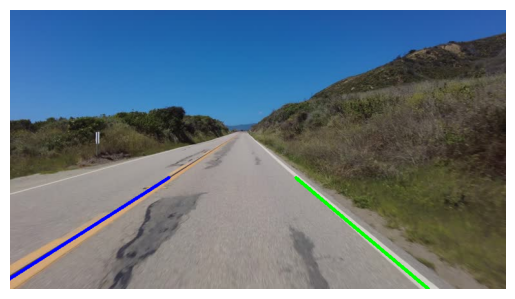

In [495]:
img_2 = lane_detection_pipeline("Road-Lane-8.png")

# Part 2 – Road Lane Detection Using Hough Transform

The second part of the assignment focuses on detecting road lane markings from an image. Lane detection is an important task in many real-world applications such as autonomous driving and driver assistance systems.

The detection process includes smoothing, edge detection, region of interest selection, and line detection using the Hough Transform.

## 3.1 Image Smoothing

The first step in lane detection is smoothing the image to reduce noise.

A 2D median filter is applied to the input image. This filtering step helps remove small variations and noise that may interfere with the edge detection process.

Smoothing ensures that the detected edges correspond to actual lane markings rather than noise artifacts.

## 3.2 Edge Detection Using Canny Algorithm

After smoothing the image, the Canny edge detection algorithm is used to identify edges.

The Canny edge detector is widely used because it provides accurate and well-defined edges. It involves several stages including gradient computation, non-maximum suppression, and thresholding.

In this assignment, relatively high threshold values are used to eliminate weak edges caused by noise and retain only the most significant edges in the image.

Insert Figure: Edge Detection Output

## 3.3 Region of Interest (ROI)

The edge detection output typically contains edges from many objects such as buildings, vehicles, and trees. However, for lane detection we are only interested in edges that belong to the road surface.

To eliminate irrelevant edges, a Region of Interest (ROI) is defined using a polygon mask. This mask selects only the lower portion of the image where road lanes are expected to appear.

Applying the ROI mask removes unwanted edges and focuses the analysis on the road region.

Insert Figure: Edge Image and ROI Output

## 3.4 Hough Transform for Line Detection

Once the relevant edges are obtained, the Hough Transform is applied to detect straight lines.

The Hough Transform represents lines in a parameter space defined by the equation:

x cos(θ) + y sin(θ) = ρ

Where:

ρ represents the perpendicular distance from the origin to the line.

θ represents the angle of the line.

Each edge point votes for possible line parameters in the (ρ, θ) parameter space. The lines that receive the highest number of votes correspond to the most likely lane lines.

## 3.5 Accumulator Space Visualization

During the Hough Transform process, an accumulator array is created to store the votes for each possible line parameter.

By visualizing the accumulator array as an image, we can observe the peaks corresponding to strong line detections. These peaks represent the parameters of the detected lane lines.

Insert Figure: Hough Accumulator Space

## 3.6 Post Processing and Line Refinement

After identifying the strongest peaks in the accumulator space, additional processing is performed to refine the detected lines.

Non-maximum suppression is applied to eliminate weaker peaks and retain only the most significant line detections. This step ensures that only the most prominent lane lines are displayed in the final output.

The detected lines are then drawn on the original image to visualize the detected road lanes.
